In [123]:
#  Data Cleaning 

In [124]:
import pandas as pd
import numpy as np

In [125]:
df = pd.read_csv("placementdata.csv")

In [126]:
print(df.head())

   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78         82   

In [127]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 1.0 MB
None


In [128]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 12)


In [129]:
# print(df["StudentID"].unique().tolist())
# print(df["CGPA"].unique().tolist())
# print(df["Internships"].unique())
# print(df["Projects"].unique())
# print(df["Workshops/Certifications"].unique())
# print(df["AptitudeTestScore"].unique())
# print(df["SoftSkillsRating"].unique())
# print(df["ExtracurricularActivities"].unique())
# print(df["PlacementTraining"].unique())
# print(df["SSC_Marks"].unique())
# print(df["HSC_Marks"].unique())
# print(df["PlacementStatus"].unique())

In [130]:
print(df.isnull().sum())

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64


In [131]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [132]:
print(df.dtypes)

StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities        str
PlacementTraining                str
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus                  str
dtype: object


In [133]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

In [134]:
columns = [
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "SSC_Marks",
    "HSC_Marks"
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [135]:
df.reset_index(drop=True, inplace=True)

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops_Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 1.0 MB


In [137]:
df.to_csv("placementdata_cleaned.csv", index=False)

print("Dataset cleaned successfully!")

Dataset cleaned successfully!


In [138]:
# EDA

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

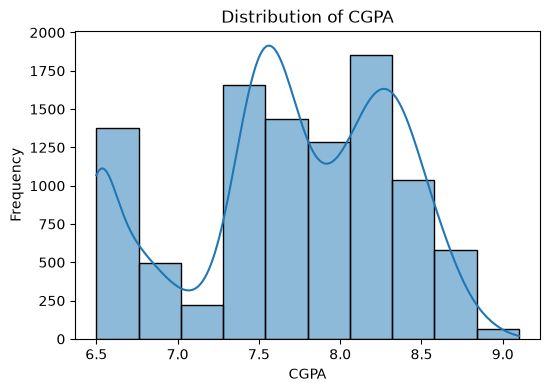

In [140]:
plt.figure(figsize=(6,4))
sns.histplot(df["CGPA"], bins=10, kde=True)
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

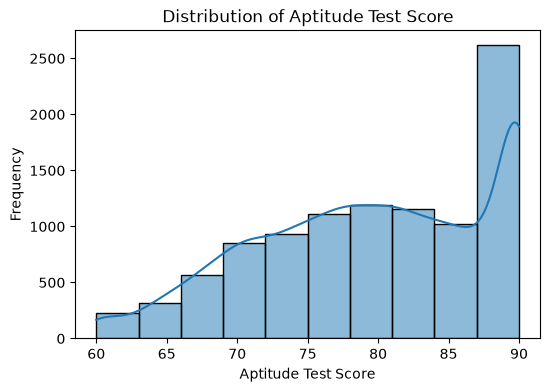

In [141]:
plt.figure(figsize=(6,4))
sns.histplot(df["AptitudeTestScore"], bins=10, kde=True)
plt.title("Distribution of Aptitude Test Score")
plt.xlabel("Aptitude Test Score")
plt.ylabel("Frequency")
plt.show()

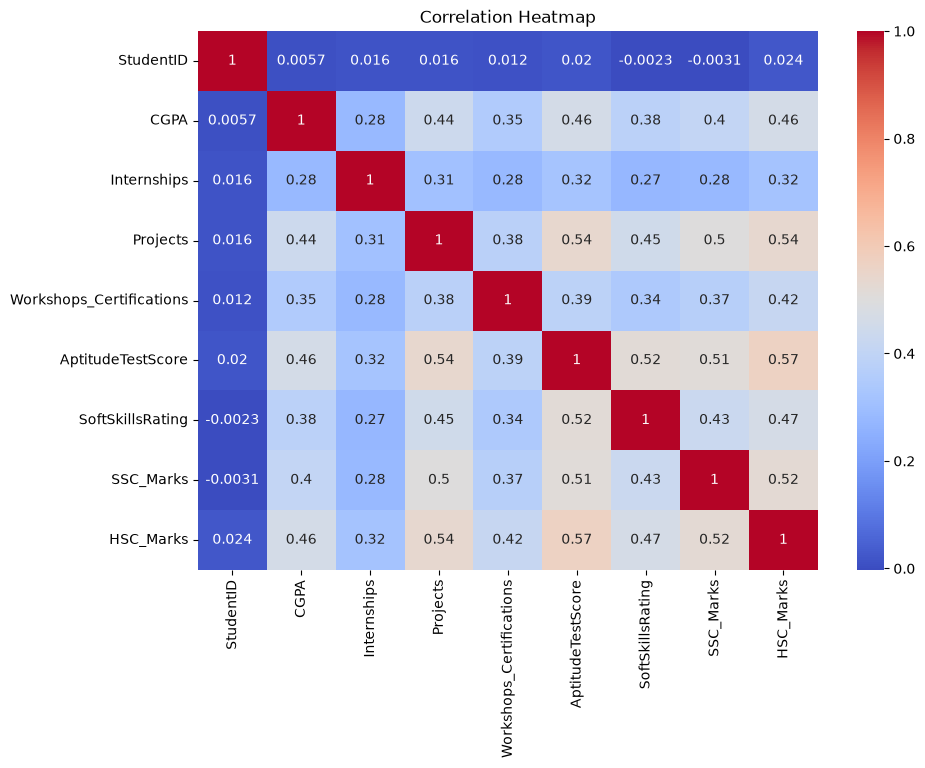

In [142]:
plt.figure(figsize=(10,7))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

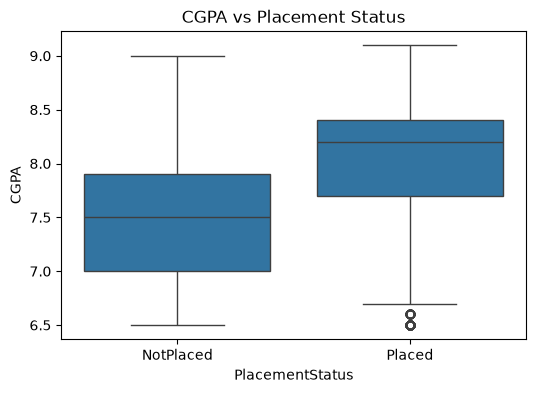

In [143]:
plt.figure(figsize=(6,4))

sns.boxplot(x="PlacementStatus",
            y="CGPA",
            data=df)

plt.title("CGPA vs Placement Status")
plt.show()

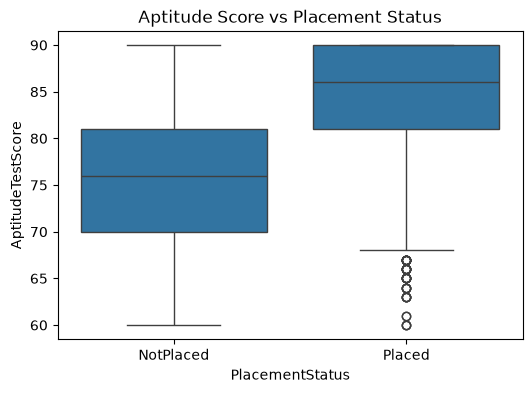

In [144]:
plt.figure(figsize=(6,4))

sns.boxplot(x="PlacementStatus",
            y="AptitudeTestScore",
            data=df)

plt.title("Aptitude Score vs Placement Status")
plt.show()

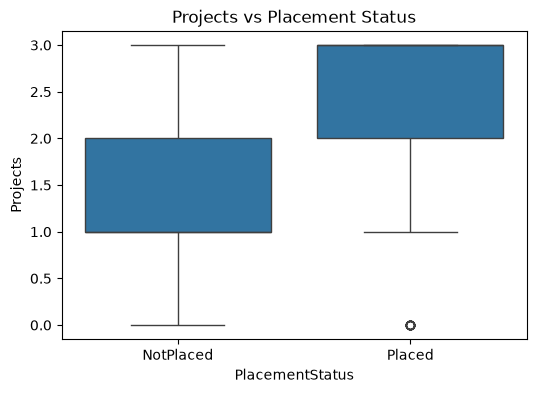

In [145]:
plt.figure(figsize=(6,4))

sns.boxplot(x="PlacementStatus",
            y="Projects",
            data=df)

plt.title("Projects vs Placement Status")
plt.show()

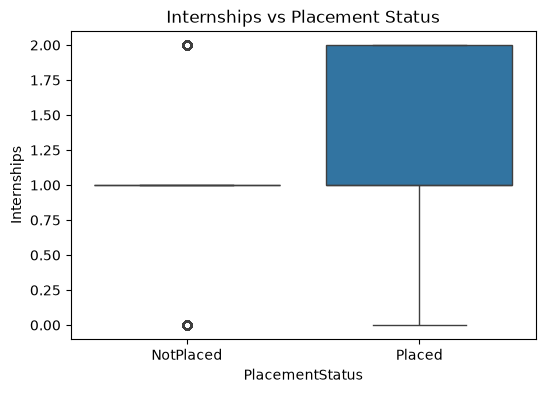

In [146]:
plt.figure(figsize=(6,4))

sns.boxplot(x="PlacementStatus",
            y="Internships",
            data=df)

plt.title("Internships vs Placement Status")
plt.show()

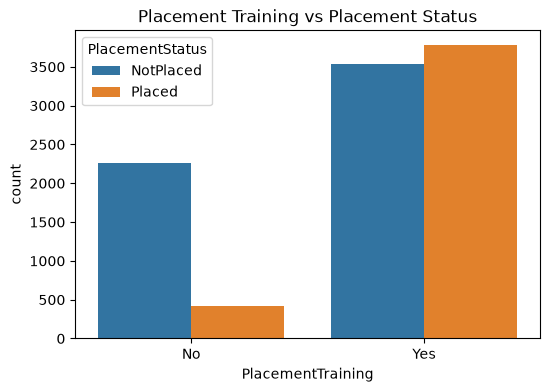

In [147]:
plt.figure(figsize=(6,4))

sns.countplot(x="PlacementTraining",
              hue="PlacementStatus",
              data=df)

plt.title("Placement Training vs Placement Status")
plt.show()

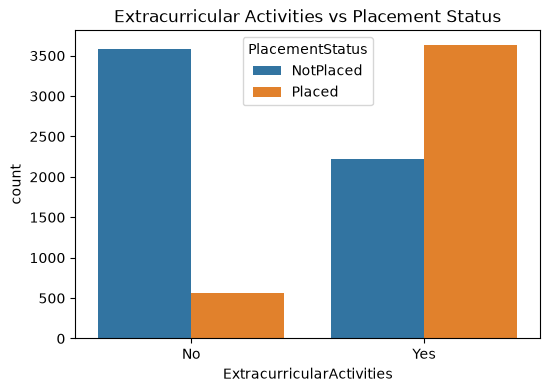

In [148]:
plt.figure(figsize=(6,4))

sns.countplot(x="ExtracurricularActivities",
              hue="PlacementStatus",
              data=df)

plt.title("Extracurricular Activities vs Placement Status")
plt.show()

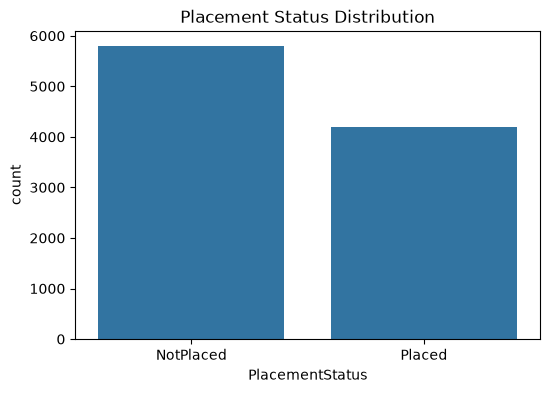

In [149]:
plt.figure(figsize=(6,4))

sns.countplot(x="PlacementStatus", data=df)

plt.title("Placement Status Distribution")
plt.show()

In [150]:
df["ExperienceScore"] = (
    df["Projects"] +
    df["Internships"] +
    df["Workshops_Certifications"]
)

print(df[["Projects", "Internships", "Workshops_Certifications", "ExperienceScore"]].head())

   Projects  Internships  Workshops_Certifications  ExperienceScore
0         1            1                         1                3
1         3            0                         2                5
2         2            1                         2                5
3         1            1                         2                4
4         2            1                         2                5


In [151]:
print(df["ExperienceScore"].describe())

count    10000.000000
mean         4.089000
std          1.816923
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max          8.000000
Name: ExperienceScore, dtype: float64


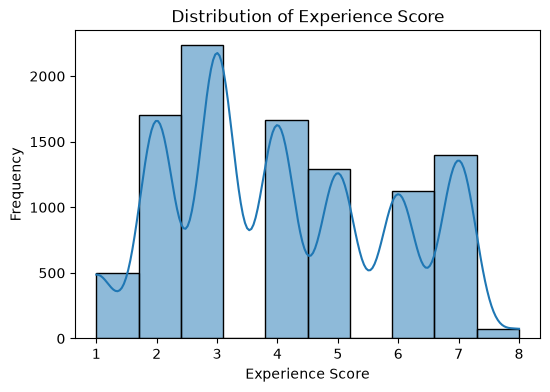

In [152]:
plt.figure(figsize=(6,4))
sns.histplot(df["ExperienceScore"], bins=10, kde=True)

plt.title("Distribution of Experience Score")
plt.xlabel("Experience Score")
plt.ylabel("Frequency")

plt.show()

In [153]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Convert categorical columns into numerical values
df["ExtracurricularActivities"] = le.fit_transform(df["ExtracurricularActivities"])
df["PlacementTraining"] = le.fit_transform(df["PlacementTraining"])
df["PlacementStatus"] = le.fit_transform(df["PlacementStatus"])

# Feature Selection
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

# Display feature and target shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 12)
Target Shape: (10000,)


In [154]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (8000, 12)
Testing Features : (2000, 12)
Training Target  : (8000,)
Testing Target   : (2000,)


In [155]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Create object
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape :", X_test_scaled.shape)

Scaled Training Data Shape: (8000, 12)
Scaled Testing Data Shape : (2000, 12)


In [156]:
# Model building

In [157]:
# 1. Linear Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

pred_lr = lr_pipeline.predict(X_test)

In [158]:
# 2. Decision Tree Regression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

pred_dt = dt_pipeline.predict(X_test)

In [159]:
# 3 Random Forest Regression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

pred_rf = rf_pipeline.predict(X_test)

In [160]:
# 4 K-Nearest Neighbors Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

pred_knn = knn_pipeline.predict(X_test)

In [161]:
# 5 Support Vector Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

svr_pipeline.fit(X_train, y_train)

pred_svr = svr_pipeline.predict(X_test)

In [162]:
# Evaluation Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [163]:
# Linear Regression
print("R² Score :", r2_score(y_test, pred_lr))
print("MAE      :", mean_absolute_error(y_test, pred_lr))
print("RMSE     :", root_mean_squared_error(y_test, pred_lr))

R² Score : 0.408840475252377
MAE      : 0.3029181793988467
RMSE     : 0.37870524863259075


In [164]:
# Decision Tree Regression
print("R² Score :", r2_score(y_test, pred_dt))
print("MAE      :", mean_absolute_error(y_test, pred_dt))
print("RMSE     :", root_mean_squared_error(y_test, pred_dt))

R² Score : -0.17887586354717921
MAE      : 0.286
RMSE     : 0.5347896782848375


In [165]:
# Random Forest Regression
r2_rf = r2_score(y_test, pred_rf)
print("Random Forest R² Score:", r2_rf)

mae_rf = mean_absolute_error(y_test, pred_rf)
print("Random Forest MAE:", mae_rf)

rmse_rf = root_mean_squared_error(y_test, pred_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R² Score: 0.3966667903249742
Random Forest MAE: 0.285785
Random Forest RMSE: 0.3825846965052314


In [166]:
# KNN Regression
print("R² Score :", r2_score(y_test, pred_knn))
print("MAE      :", mean_absolute_error(y_test, pred_knn))
print("RMSE     :", root_mean_squared_error(y_test, pred_knn))

R² Score : 0.3050403126082012
MAE      : 0.2756
RMSE     : 0.4106093033529562


In [167]:
# Support Vector Regression
print("R² Score :", r2_score(y_test, pred_svr))
print("MAE      :", mean_absolute_error(y_test, pred_svr))
print("RMSE     :", root_mean_squared_error(y_test, pred_svr))

R² Score : 0.3547704553684874
MAE      : 0.2581206263622688
RMSE     : 0.39564538218685624


In [168]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                      Feature  Importance
10                  HSC_Marks    0.331915
5           AptitudeTestScore    0.131057
0                   StudentID    0.131051
9                   SSC_Marks    0.088752
1                        CGPA    0.080473
6            SoftSkillsRating    0.067024
7   ExtracurricularActivities    0.045296
11            ExperienceScore    0.035880
4    Workshops_Certifications    0.026312
3                    Projects    0.023282
8           PlacementTraining    0.020168
2                 Internships    0.018792


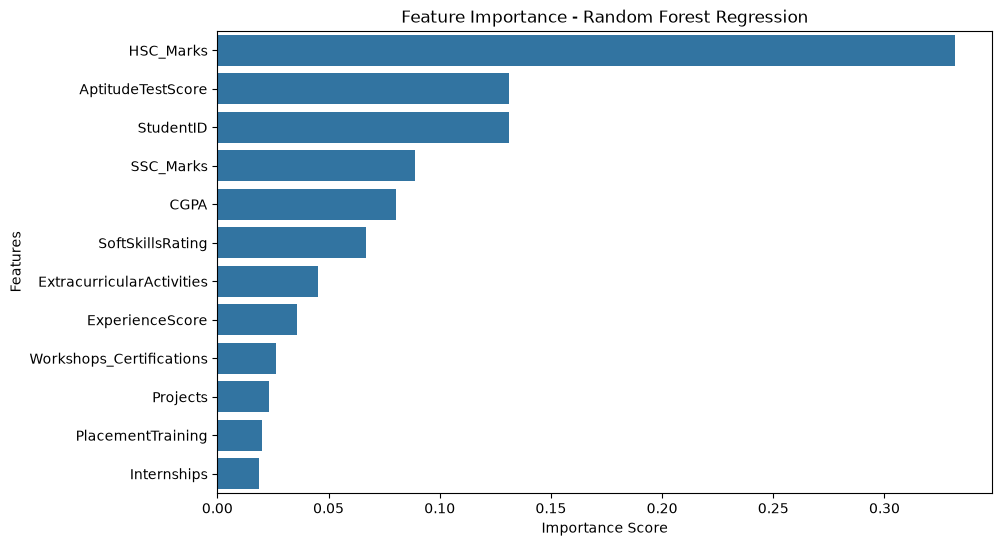

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest Regression")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [174]:
print(X.columns)

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops_Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'ExperienceScore'],
      dtype='str')


In [175]:
print(X.shape)

(10000, 12)


In [176]:
import joblib

In [177]:
joblib.dump(rf_pipeline, "placement_package_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [178]:
model = joblib.load("placement_package_prediction_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [179]:
prediction = model.predict(X_test)

print(prediction[:10])

[0.   0.39 0.   1.   0.68 0.94 0.59 0.09 0.31 0.35]
